## Setup:
Setting up our mutual funds. Note that we have 4 mutual funds [A,B,C,D] with the following distributions/returns:

- A: $Unif[-40\%, 60\%]$
- B: $Unif[-10\%, 24\%]$
- C: $Normal(7\%, (2\%)^2)$
- D: $Unif[5\%, 7\%]$

We will also start with `$1,000,000`. Our goal will be to determine the best investment strategy.

The code below contains several functions about portfolios, which are an array of 4 numbers indicating the amount invested in each stock respectively.

In [ ]:
# %pip install numpy matplotlib
# uncomment during first run to install dependencies

import numpy as np
import matplotlib.pyplot as plt

NUM_SIMS = 100000
SEED = 0
SHORT_TERM_YEARS = 3
LONG_TERM_YEARS = 10
RETIREMENT_YEARS = 50

np.random.seed(SEED)

def setup_portfolios(starting_portfolio: list[float], num_portfolios: int) -> list[list[float]]:
        return [starting_portfolio.copy() for _ in range(num_portfolios)]

# Returns a portfolio containing the mean value of each stock across all portfolios
def get_mean_portfolio(portfolios: list[list[float]]) -> np.ndarray:
        return np.mean(portfolios, axis=0)

# Returns an array of the values of a specific stock type across all portfolios
def filter_portfolios(portfolios: list[list[float]], stock_type: str) -> np.ndarray:
        
        np_arr = np.array(portfolios)

        match stock_type:
                case 'A':
                        return np_arr[:, 0]
                case 'B':
                        return np_arr[:, 1]
                case 'C':
                        return np_arr[:, 2]
                case 'D':
                        return np_arr[:, 3]
                case _:
                        raise ValueError(f"Invalid stock type: {stock_type}")

def get_values(portfolios: list[list[float]]) -> np.ndarray:
        return np.sum(portfolios, axis=1)

# Returns the number of values that have a total value greater than the threshold
def percent_of_values_above(values: np.ndarray, threshold: float) -> float:
        return np.count_nonzero(values > threshold) / len(values) * 100

# Returns the number of values that have a total value less than or equal to the threshold
def percent_of_values_below(values: np.ndarray, threshold: float) -> float:
        return np.count_nonzero(values <= threshold) / len(values) * 100

def percent_of_return(end, start) -> float:
        return (end - start) / start * 100

def percent_of_outliers(values: np.ndarray) -> float:
        q25 = np.percentile(values, 25)
        q75 = np.percentile(values, 75)
        iqr = q75 - q25
        lower_bound = q25 - 1.5 * iqr
        upper_bound = q75 + 1.5 * iqr
        outliers = np.sum((values < lower_bound) | (values > upper_bound))
        return outliers / len(values) * 100

def print_stats(values: np.ndarray, header: str = "Stats:", footer: str = ""):
        mean = np.mean(values)
        median = np.median(values)
        q25 = np.percentile(values, 25)
        q75 = np.percentile(values, 75)
        iqr_value = q75 - q25
        outlier_percentage = percent_of_outliers(values)
        std = np.std(values)

        print(header)
        print(f"Mean: ${mean:,.2f}")
        print(f"Standard Deviation: ${std:,.2f}")
        print(f"Median: ${median:,.2f}")
        print(f"Q1 (25th percentile): ${q25:,.2f}")
        print(f"Q3 (75th percentile): ${q75:,.2f}")
        print(f"Min: ${np.min(values):,.2f}")
        print(f"Max: ${np.max(values):,.2f}")
        print(f"IQR: ${iqr_value:,.2f}")
        print(f"Percentage of outliers: {outlier_percentage:.2f}%")
        print(footer)

# Simulates one year of returns for a single portfolio
def simulate_once(portfolio: list[float]):
        change_a = np.random.uniform(-0.4, 0.6)
        change_b = np.random.uniform(-0.1, 0.24)
        change_c = np.random.normal(0.07, 0.02)
        change_d = np.random.uniform(0.05, 0.07)

        portfolio[0] *= (1 + change_a)
        portfolio[1] *= (1 + change_b)
        portfolio[2] *= (1 + change_c)
        portfolio[3] *= (1 + change_d)

# Simulates multiple years of returns for a list of portfolios
def simulate_multiple(portfolios: list[list[float]], num_years: int):
        for _ in range(num_years):
                for portfolio in portfolios:
                        simulate_once(portfolio)

### Question 1:

##### What is the expected return if you invest option A for 3 years? 

In [68]:
PORTFOLIO = [1000000.0, 1000000.0, 1000000.0, 1000000.0]  # $1,000,000 in asset A, $0 in B, C, D

portfolios = setup_portfolios(PORTFOLIO, NUM_SIMS)

simulate_multiple(portfolios, SHORT_TERM_YEARS)

fund_A_values = filter_portfolios(portfolios, "A")
mean_A = np.mean(fund_A_values)

print(f"Average value of asset A after {SHORT_TERM_YEARS} years: ${mean_A:,.2f}")
print(f"Average return of asset A after {SHORT_TERM_YEARS} years: {percent_of_return(mean_A, 1000000):.2f}%")
print(f"Minimum portfolio value: ${np.min(fund_A_values):,.2f}")
print(f"Maximum portfolio value: ${np.max(fund_A_values):,.2f}")

q75, q25 = np.percentile(fund_A_values, [75, 25])
iqr = q75 - q25
print(f"IQR: ${iqr:,.2f}")

Average value of asset A after 3 years: $1,332,978.55
Average return of asset A after 3 years: 33.30%
Minimum portfolio value: $232,680.14
Maximum portfolio value: $4,032,441.91
IQR: $831,237.23


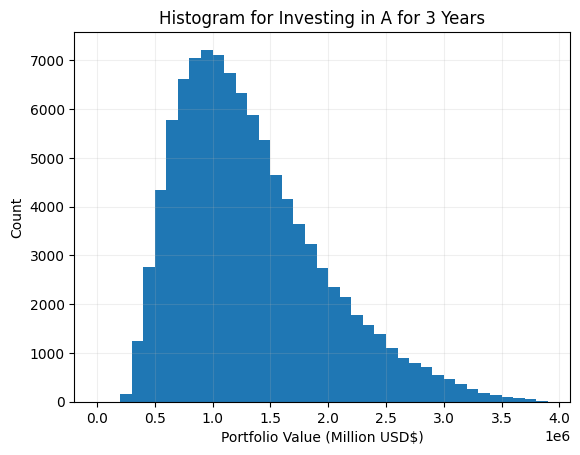

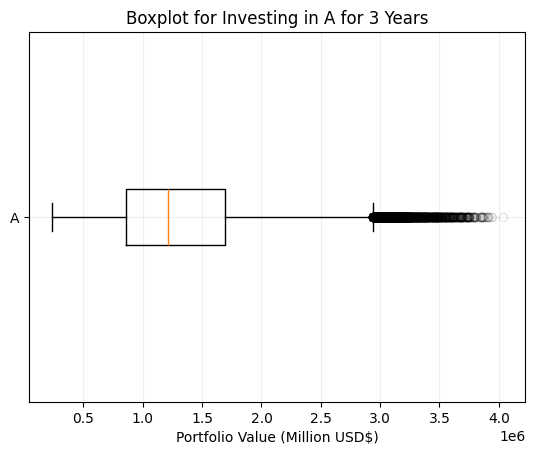

In [69]:
# plots for fund A

plt.figure(1)
histogram = plt.hist(fund_A_values, bins=range(0, 4000000, 100000)) # each bin will be 100k
plt.grid(alpha=0.2)
plt.title("Histogram for Investing in A for 3 Years")
plt.xlabel("Portfolio Value (Million USD$)")
plt.ylabel("Count")

plt.figure(2)
box_plot = plt.boxplot(fund_A_values, vert=False, flierprops={"alpha": 0.1})
plt.grid(alpha=0.2)
plt.title("Boxplot for Investing in A for 3 Years")
plt.xlabel("Portfolio Value (Million USD$)")
plt.yticks([1], ["A"])

plt.show()

##### What is the probability that your profit is more than 25%? 

$ P(T > 1,250,000) =  ? $

In [70]:
print(f"Percentage of portfolios with over $1,250,000 after {SHORT_TERM_YEARS} years: {percent_of_values_above(fund_A_values, 1250000):.2f}%")

Percentage of portfolios with over $1,250,000 after 3 years: 47.73%


##### What is the probability that you lose 25% of your money?

$ P(T \le 750,000) = ?$

In [71]:
print(f"Percentage of portfolios with $750,000 or less after {SHORT_TERM_YEARS} years: {percent_of_values_below(fund_A_values, 750000):.2f}%")

Percentage of portfolios with $750,000 or less after 3 years: 17.59%


### Question 2:
##### What are your answers if you invest in fund B or C? And what is your recommendation for the best option?

In [72]:
# calculations for fund B
fund_B_values = filter_portfolios(portfolios, "B")
mean_B = np.mean(fund_B_values)

print(f"Average value of asset B after {SHORT_TERM_YEARS} years: ${mean_B:,.2f}")
print(f"Average return of asset B after {SHORT_TERM_YEARS} years: {percent_of_return(mean_B, 1000000):.2f}%")
print(f"Minimum portfolio value: ${np.min(fund_B_values):,.2f}")
print(f"Maximum portfolio value: ${np.max(fund_B_values):,.2f}")

q75, q25 = np.percentile(fund_B_values, [75, 25])
iqr = q75 - q25
print(f"IQR: ${iqr:,.2f}")

print(f"Percentage of portfolios with over $1,250,000 after {SHORT_TERM_YEARS} years: {percent_of_values_above(fund_B_values, 1250000):.2f}%")
print(f"Percentage of portfolios with $750,000 or less after {SHORT_TERM_YEARS} years: {percent_of_values_below(fund_B_values, 750000):.2f}%")

Average value of asset B after 3 years: $1,225,102.33
Average return of asset B after 3 years: 22.51%
Minimum portfolio value: $741,571.19
Maximum portfolio value: $1,886,874.72
IQR: $273,648.07
Percentage of portfolios with over $1,250,000 after 3 years: 42.71%
Percentage of portfolios with $750,000 or less after 3 years: 0.00%


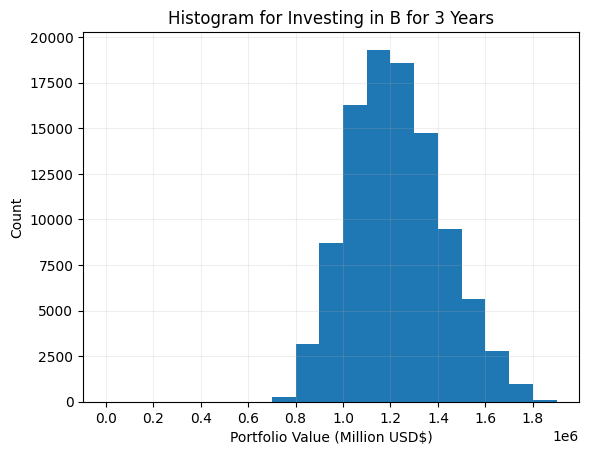

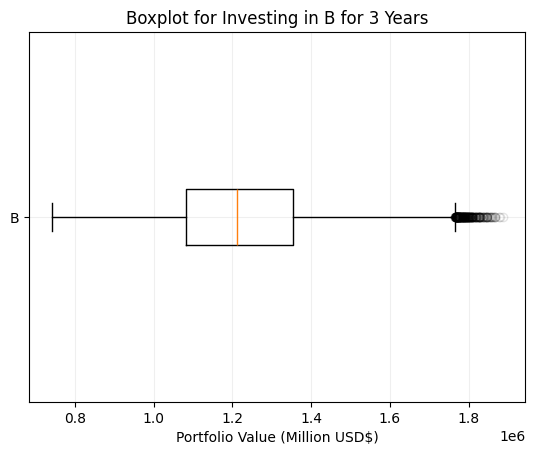

In [73]:
# plots for fund B

plt.figure(3)
histogram = plt.hist(fund_B_values, bins=range(0, 2000000, 100000)) # each bin will be 100k
plt.xticks(ticks=range(0,2000000,200000))
plt.grid(alpha=0.2)
plt.title("Histogram for Investing in B for 3 Years")
plt.xlabel("Portfolio Value (Million USD$)")
plt.ylabel("Count")

plt.figure(4)
box_plot = plt.boxplot(fund_B_values, vert=False, flierprops={"alpha": 0.1})
plt.grid(alpha=0.2)
plt.title("Boxplot for Investing in B for 3 Years")
plt.xlabel("Portfolio Value (Million USD$)")
plt.yticks([1], ["B"])

plt.show()


In [74]:
# calculations for fund C
fund_C_values = filter_portfolios(portfolios, "C")
mean_C = np.mean(fund_C_values)

print(f"Average value of asset C after {SHORT_TERM_YEARS} years: ${mean_C:,.2f}")
print(f"Average return of asset C after {SHORT_TERM_YEARS} years: {percent_of_return(mean_C, 1000000):.2f}%")
print(f"Minimum portfolio value: ${np.min(fund_C_values):,.2f}")
print(f"Maximum portfolio value: ${np.max(fund_C_values):,.2f}")

q75, q25 = np.percentile(fund_C_values, [75, 25])
iqr = q75 - q25
print(f"IQR: ${iqr:,.2f}")

print(f"Percentage of portfolios with over $1,250,000 after {SHORT_TERM_YEARS} years: {percent_of_values_above(fund_C_values, 1250000):.2f}%")
print(f"Percentage of portfolios with $750,000 or less after {SHORT_TERM_YEARS} years: {percent_of_values_below(fund_C_values, 750000):.2f}%")


Average value of asset C after 3 years: $1,225,044.17
Average return of asset C after 3 years: 22.50%
Minimum portfolio value: $1,052,171.33
Maximum portfolio value: $1,402,065.01
IQR: $53,746.51
Percentage of portfolios with over $1,250,000 after 3 years: 26.40%
Percentage of portfolios with $750,000 or less after 3 years: 0.00%


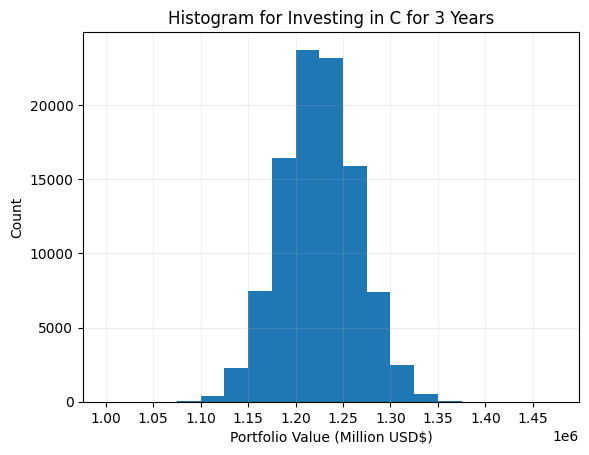

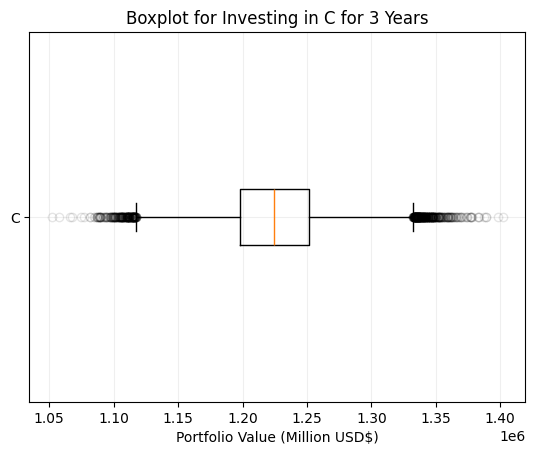

In [75]:
# plots for fund C

plt.figure(5)
histogram = plt.hist(fund_C_values, bins=range(1000000, 1500000, 25000)) # each bin will be 25k
plt.xticks(ticks=range(1000000,1500000,50000))
plt.grid(alpha=0.2)
plt.title("Histogram for Investing in C for 3 Years")
plt.xlabel("Portfolio Value (Million USD$)")
plt.ylabel("Count")

plt.figure(6)
box_plot = plt.boxplot(fund_C_values, vert=False, flierprops={"alpha": 0.1})
plt.grid(alpha=0.2)
plt.title("Boxplot for Investing in C for 3 Years")
plt.xlabel("Portfolio Value (Million USD$)")
plt.yticks([1], ["C"])

plt.show()


##### What about investing everything in fund D for 3 years?

In [76]:
# calculations for fund D
fund_D_values = filter_portfolios(portfolios, "D")
mean_D = np.mean(fund_D_values)

print(f"Average value of asset D after {SHORT_TERM_YEARS} years: ${mean_D:,.2f}")
print(f"Average return of asset D after {SHORT_TERM_YEARS} years: {percent_of_return(mean_D, 1000000):.2f}%")
print(f"Minimum portfolio value: ${np.min(fund_D_values):,.2f}")
print(f"Maximum portfolio value: ${np.max(fund_D_values):,.2f}")

q75, q25 = np.percentile(fund_D_values, [75, 25])
iqr = q75 - q25
print(f"IQR: ${iqr:,.2f}")

print(f"Percentage of portfolios with over $1,250,000 after {SHORT_TERM_YEARS} years: {percent_of_values_above(fund_D_values, 1250000):.2f}%")
print(f"Percentage of portfolios with $750,000 or less after {SHORT_TERM_YEARS} years: {percent_of_values_below(fund_D_values, 750000):.2f}%")

Average value of asset D after 3 years: $1,191,083.07
Average return of asset D after 3 years: 19.11%
Minimum portfolio value: $1,158,370.78
Maximum portfolio value: $1,224,486.87
IQR: $15,952.20
Percentage of portfolios with over $1,250,000 after 3 years: 0.00%
Percentage of portfolios with $750,000 or less after 3 years: 0.00%


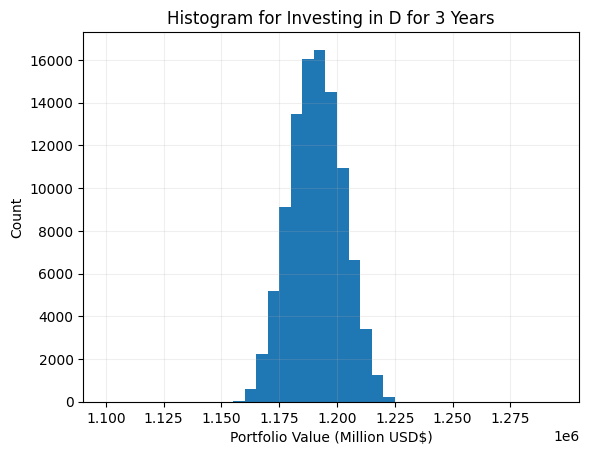

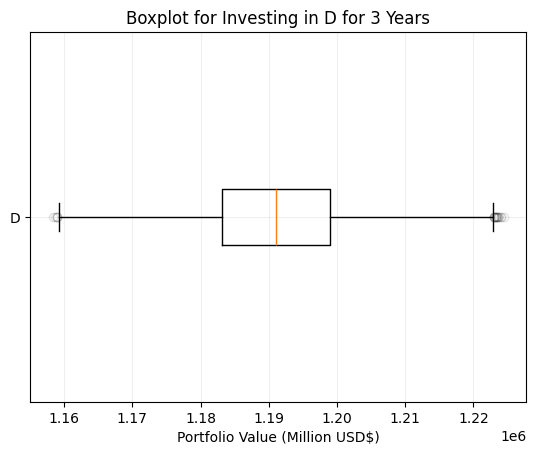

In [77]:
# plots for fund D

plt.figure(7)
histogram = plt.hist(fund_D_values, bins=range(1100000, 1300000, 5000)) # each bin will be 5k
plt.xticks(ticks=range(1100000,1300000,25000))
plt.grid(alpha=0.2)
plt.title("Histogram for Investing in D for 3 Years")
plt.xlabel("Portfolio Value (Million USD$)")
plt.ylabel("Count")

plt.figure(8)
box_plot = plt.boxplot(fund_D_values, vert=False, flierprops={"alpha": 0.1})
plt.grid(alpha=0.2)
plt.title("Boxplot for Investing in D for 3 Years")
plt.xlabel("Portfolio Value (Million USD$)")
plt.yticks([1], ["D"])

plt.show()


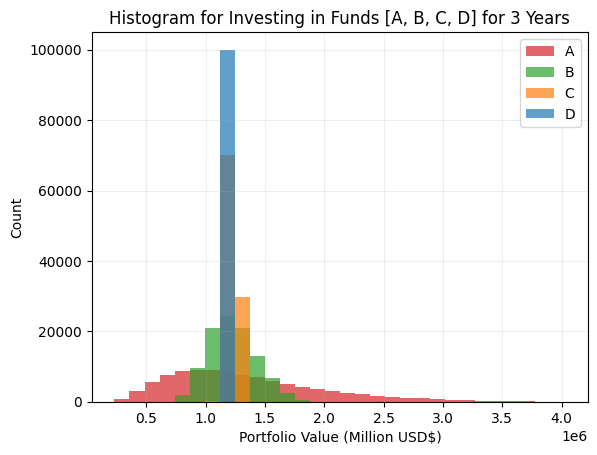

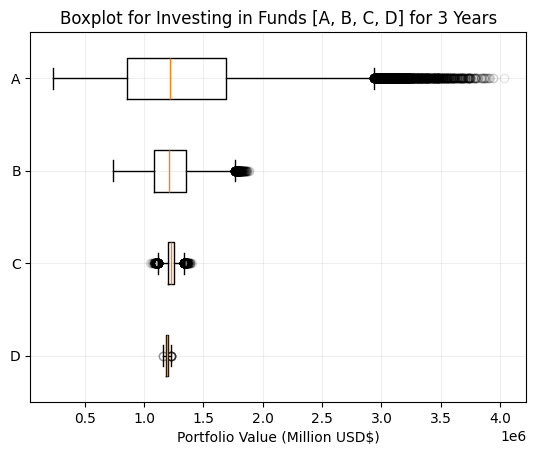

In [78]:
# combining outcomes for funds A, B, C, D into into a single plot for simplicity

plt.figure(9)
stacked_hist = plt.hist([fund_D_values, fund_C_values, fund_B_values, fund_A_values], histtype="stepfilled", bins=30, label=["D", "C", "B", "A"], alpha=0.7)
plt.grid(alpha=0.2)
plt.title("Histogram for Investing in Funds [A, B, C, D] for 3 Years")
plt.legend()
plt.xlabel("Portfolio Value (Million USD$)")
plt.ylabel("Count")
plt.show()

plt.figure(10)
# multi_boxplot = plt.boxplot([fund_A_values, fund_B_values, fund_C_values, fund_D_values], label=["A", "B", "C", "D"], vert=False, flierprops={"alpha": 0.1})
multi_boxplot = plt.boxplot([fund_D_values, fund_C_values, fund_B_values, fund_A_values], label=["D", "C", "B", "A"], vert=False, flierprops={"alpha": 0.1})
plt.grid(alpha=0.2)
plt.title("Boxplot for Investing in Funds [A, B, C, D] for 3 Years")
plt.yticks(ticks=[1,2,3,4], labels=["D", "C", "B", "A"])
plt.xlabel("Portfolio Value (Million USD$)")
plt.show()

*So which is best?*

***markdown cell for analysis!!!***

### Question 3:
##### How will your answer/recommendation change if you are planning for 10 years, instead of 3 years?

In [79]:
portfolios = setup_portfolios([1000000.0, 1000000.0, 1000000.0, 1000000.0], NUM_SIMS)
simulate_multiple(portfolios, LONG_TERM_YEARS)

fund_A_values = filter_portfolios(portfolios, "A")
fund_B_values = filter_portfolios(portfolios, "B")
fund_C_values = filter_portfolios(portfolios, "C")
fund_D_values = filter_portfolios(portfolios, "D")

Here are some statistics about the funds:

In [80]:
print_stats(fund_A_values, "Statistics for Fund A after 10 Years")
print_stats(fund_B_values, "Statistics for Fund B after 10 Years")
print_stats(fund_C_values, "Statistics for Fund C after 10 Years")
print_stats(fund_D_values, "Statistics for Fund D after 10 Years")

Statistics for Fund A after 10 Years
Mean: $2,588,001.37
Standard Deviation: $2,491,665.52
Median: $1,823,984.31
Q1 (25th percentile): $1,001,964.89
Q3 (75th percentile): $3,284,835.49
Min: $48,099.65
Max: $36,668,648.54
IQR: $2,282,870.61
Percentage of outliers: 6.28%

Statistics for Fund B after 10 Years
Mean: $1,964,207.71
Standard Deviation: $577,245.60
Median: $1,888,561.51
Q1 (25th percentile): $1,546,283.13
Q3 (75th percentile): $2,300,943.13
Min: $486,470.36
Max: $5,609,621.65
IQR: $754,660.00
Percentage of outliers: 1.71%

Statistics for Fund C after 10 Years
Mean: $1,966,873.81
Standard Deviation: $116,125.12
Median: $1,963,680.60
Q1 (25th percentile): $1,887,275.09
Q3 (75th percentile): $2,043,370.20
Min: $1,492,286.51
Max: $2,481,477.11
IQR: $156,095.10
Percentage of outliers: 0.74%

Statistics for Fund D after 10 Years
Mean: $1,790,862.52
Standard Deviation: $30,792.55
Median: $1,790,694.54
Q1 (25th percentile): $1,769,692.23
Q3 (75th percentile): $1,811,774.00
Min: $1,666

Here are the plots:

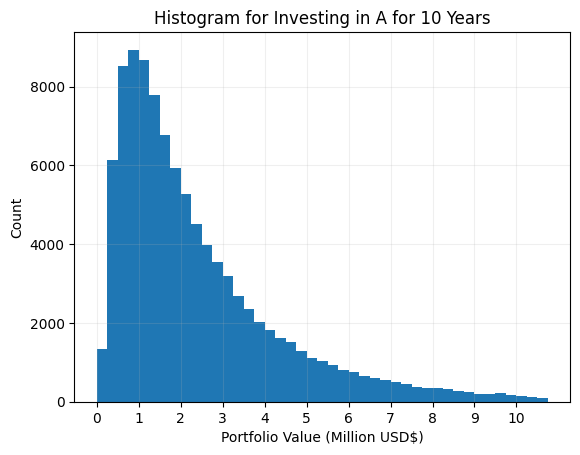

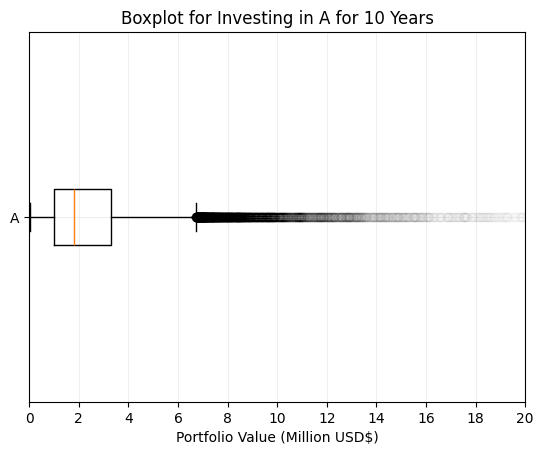

In [81]:
plt.figure(11)
histogram = plt.hist(fund_A_values, bins=range(0, 11000000, 250000)) # each bin will be 250k
plt.grid(alpha=0.2)
plt.title("Histogram for Investing in A for 10 Years")
plt.xlabel("Portfolio Value (Million USD$)")
plt.xticks(range(0,11000000, 1000000), list(range(0,11))) # type: ignore
plt.ylabel("Count")

plt.figure(12)
box_plot = plt.boxplot(fund_A_values, vert=False, flierprops={"alpha": 0.01})
plt.grid(alpha=0.2)
plt.title("Boxplot for Investing in A for 10 Years")
plt.xlabel("Portfolio Value (Million USD$)")
plt.xticks(range(0, 21000000, 2000000), list(range(0,21,2))) # type: ignore
plt.yticks([1], ["A"])
plt.xlim(0,20000000)

plt.show()

### Question 4:

##### Will it be a better strategy if we invest `$500,000` in fund A and `$500,000` in fund D? 

##### Or how about `$600,000` in fund B and `$400,000` in fund C?

##### Will it be a better strategy if we invest `$500,000` in fund A, `$300,000` in fund B and `$200,000` in fund C?

##### How about investing `$250,000` in each fund?

### Question 5:

##### What is the best strategy you would recommend?

markdown block: ***will put answer here !!!***